# "Programmeerimine" kursuse katvuse analüüs

## 0. Setup



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Plot styling
plt.rcParams.update({
    "figure.dpi": 150,
    "figure.figsize": (10, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

BLOOM_ORDER = [
    "1 - Meenutamine",
    "2 - Mõistmine",
    "3 - Rakendamine",
    "4 - Analüüsimine",
    "5 - Hindamine",
    "6 - Loomine",
]

BLOOM_COLOURS = {
    "1 - Meenutamine":  "#b3cde3",
    "2 - Mõistmine":"#8db0d0",
    "3 - Rakendamine":     "#4d9abf",
    "4 - Analüüsimine":   "#2166ac",
    "5 - Hindamine":  "#053061",
    "6 - Loomine":    "#011936",
}

TYPE_COLOURS = {
    "Kodu":    "#4d9abf",
    "Harjutus":"#2c7bb6",
    "Lisa":    "#d9a62e",
}

In [2]:
# Data
from google.colab import drive
drive.mount('/content/drive')

### Muutuja!
DATA_PATH = "/content/drive/My Drive/Colab Notebooks/Baka/classifications - classification.csv.csv"

df_raw = pd.read_csv(DATA_PATH)
print(f"Raw shape: {df_raw.shape}")

BLOOM_TRANSLATE = {
    "1 - Remember": "1 - Meenutamine",
    "2 - Understand": "2 - Mõistmine",
    "3 - Apply": "3 - Rakendamine",
    "4 - Analyse": "4 - Analüüsimine",
    "5 - Evaluate": "5 - Hindamine",
    "6 - Create": "6 - Loomine",
}

df_raw["Bloomi tase"] = df_raw["Bloomi tase"].replace(BLOOM_TRANSLATE)

df_raw.head()


Mounted at /content/drive
Raw shape: (98, 14)


,#,Nädal,Teema,Tüüp,Kohustuslik,ÜL_ID,ÜL_nimi,ÜL_teema,Bloomi tase,ÕV1,ÕV2,ÕV3,ÕV4,ÕV5
0,1,1,"print, input, muutujad, tüübid",Kodu,Jah,1.1,Õunad,"input, väärtustamine, arvutamine, print",3 - Rakendamine,1.0,1.0,NaN,1.0,NaN
1,2,1,"print, input, muutujad, tüübid",Kodu,Jah,1.2,Arvutamine,"input, arvutamine, print",3 - Rakendamine,1.0,1.0,NaN,1.0,NaN
2,3,1,"print, input, muutujad, tüübid",Harjutus,Jah,1.3,Tervitamine,"input, väärtustamine, print",2 - Mõistmine,1.0,1.0,NaN,NaN,NaN
3,4,1,"print, input, muutujad, tüübid",Harjutus,Jah,1.4,Aastaajad,"input, tingimuslause, võrdlus, print",3 - Rakendamine,1.0,1.0,NaN,1.0,NaN
4,5,1,"print, input, muutujad, tüübid",Harjutus,Jah,1.5,Pitsa hind,"input, import, arvutamine",3 - Rakendamine,1.0,1.0,NaN,1.0,NaN


---
## 1. Andmestiku ülevaade

Enne analüüsi:
- Kordusnädalate eemaldamine
- Ülesandetüüpide eraldamine
- Veeruväärtuste kontroll


In [3]:
# drop Kordamine
df = df_raw[df_raw["Tüüp"] != "—"].copy()

# Normalise Bloom column
df["Bloomi tase"] = df["Bloomi tase"].str.strip()

# ÕV cols — fill NaN with 0 and cast to int
ov_cols = ["ÕV1", "ÕV2", "ÕV3", "ÕV4", "ÕV5"]
df[ov_cols] = df[ov_cols].fillna(0).astype(int)


df_mandatory = df[df["Kohustuslik"] == "Jah"].copy()
df_optional  = df[df["Kohustuslik"] == "Ei"].copy()

df["Bloom_num"] = df["Bloomi tase"].str.extract(r"(\d)").astype(float)
df_mandatory["Bloom_num"] = df_mandatory["Bloomi tase"].str.extract(r"(\d)").astype(float)
df_optional["Bloom_num"] = df_optional["Bloomi tase"].str.extract(r"(\d)").astype(float)

print(f"Total exercises (excl. revision weeks): {len(df)}")
print(f"  Mandatory (Kodu + Harjutus):          {len(df_mandatory)}")
print(f"  Optional  (Lisa):                     {len(df_optional)}")
print()
print("Exercise counts by type:")
print(df["Tüüp"].value_counts())


Total exercises (excl. revision weeks): 96
  Mandatory (Kodu + Harjutus):          85
  Optional  (Lisa):                     11

Exercise counts by type:
Tüüp
Harjutus    51
Kodu        34
Lisa        11
Name: count, dtype: int64


In [4]:
# Table 2: Ülesannete arv nädala ja tüübi kaupa
table1 = (
    df.groupby(["Nädal", "Tüüp"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Kodu", "Harjutus", "Lisa"], fill_value=0)
)
table1["Kokku"] = table1.sum(axis=1)
table1.index.name = "Nädal"
print("Table 2: Ülesannete arv nädala ja tüübi kaupa")
print(table1.to_string())


Table 2: Ülesannete arv nädala ja tüübi kaupa
Tüüp   Kodu  Harjutus  Lisa  Kokku
Nädal                             
1         2         4     1      7
2         4         4     1      9
3         3         4     1      8
4         3         4     1      8
5         3         4     1      8
7         3         4     1      8
8         3         4     1      8
9         2         4     1      7
10        3         4     1      8
11        2         4     0      6
13        1         3     2      6
14        2         4     0      6
15        3         4     0      7


---
## 2. Teemade katvus


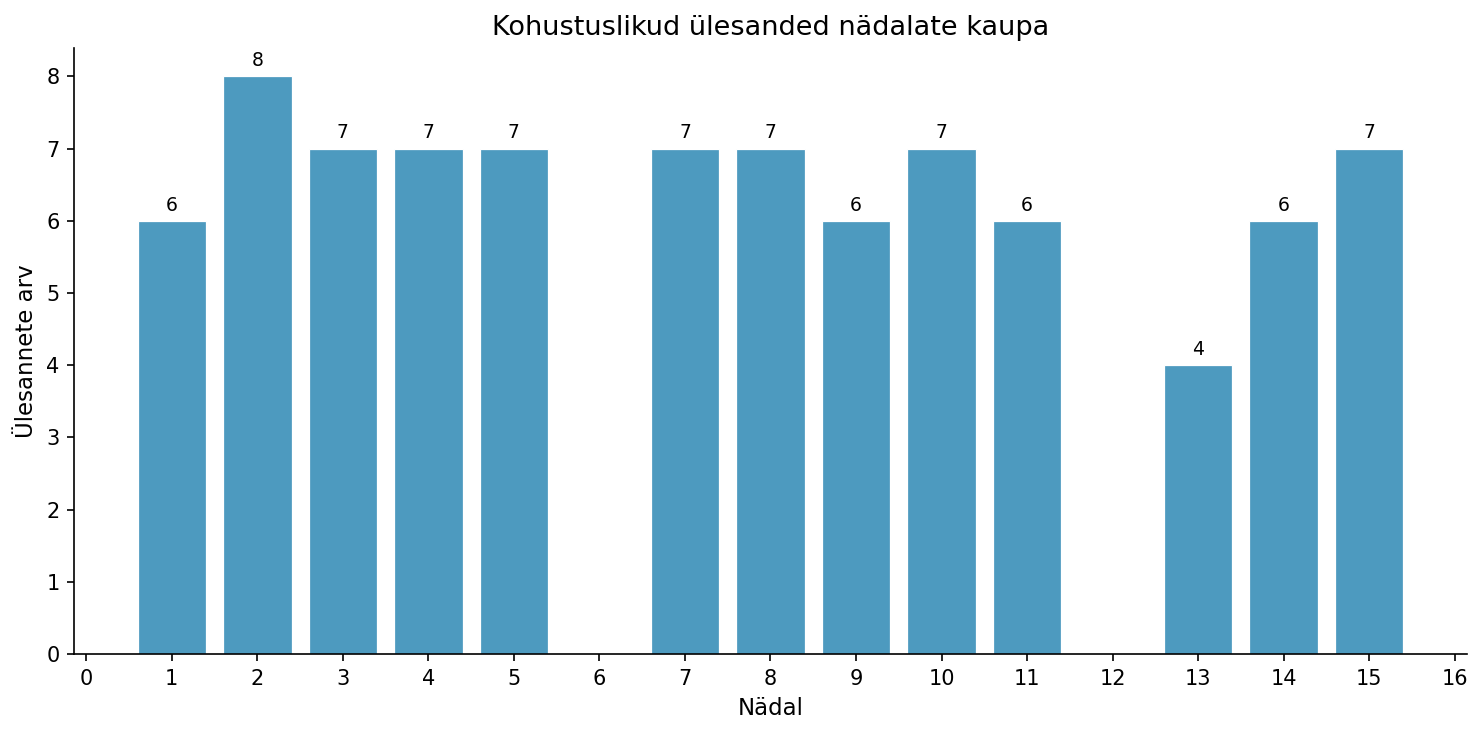

Saved


In [5]:
# Kohustuslikud ül. (Kodu + Harjutus)
week_counts = df_mandatory.groupby("Nädal").size().reset_index(name="Count")

fig, ax = plt.subplots()
bars = ax.bar(
    week_counts["Nädal"],
    week_counts["Count"],
    color="#4d9abf",
    edgecolor="white",
    linewidth=0.6,
)
ax.set_xlabel("Nädal")
ax.set_ylabel("Ülesannete arv")
ax.set_title("Kohustuslikud ülesanded nädalate kaupa")
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.bar_label(bars, padding=3, fontsize=9)
plt.tight_layout()
plt.savefig("fig1_exercises_per_week.png", bbox_inches="tight")
plt.show()
print("Saved")


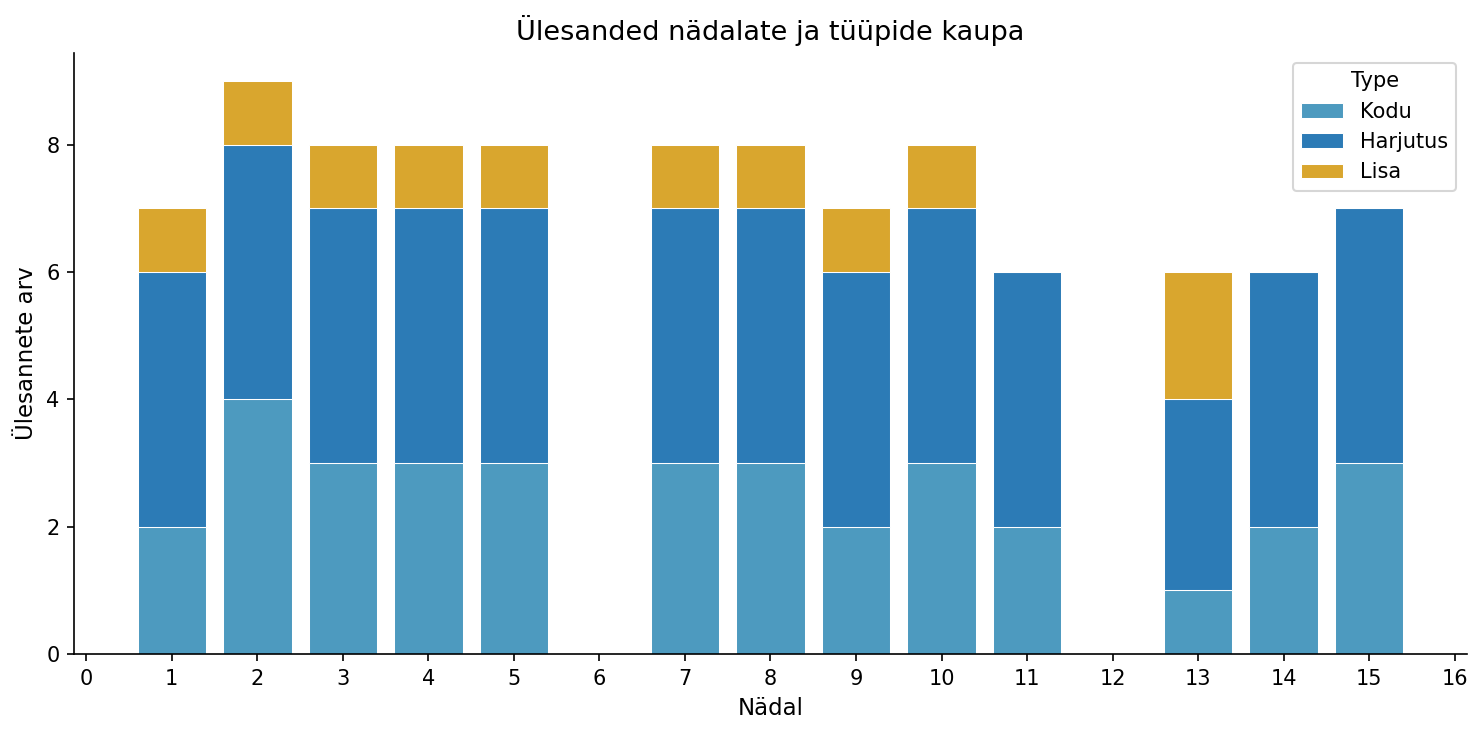

Saved


In [6]:
# Kõik ül. + lisa
week_type = (
    df.groupby(["Nädal", "Tüüp"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["Kodu", "Harjutus", "Lisa"], fill_value=0)
)

fig, ax = plt.subplots()
bottom = np.zeros(len(week_type))
for ttype in ["Kodu", "Harjutus", "Lisa"]:
    vals = week_type[ttype].values
    ax.bar(
        week_type.index,
        vals,
        bottom=bottom,
        label=ttype,
        color=TYPE_COLOURS[ttype],
        edgecolor="white",
        linewidth=0.5,
    )
    bottom += vals

ax.set_xlabel("Nädal")
ax.set_ylabel("Ülesannete arv")
ax.set_title("Ülesanded nädalate ja tüüpide kaupa")
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.legend(title="Type")
plt.tight_layout()
plt.savefig("fig2_exercises_per_week_stacked.png", bbox_inches="tight")
plt.show()
print("Saved")


---
## 3. Bloomi taksonoomia jaotus


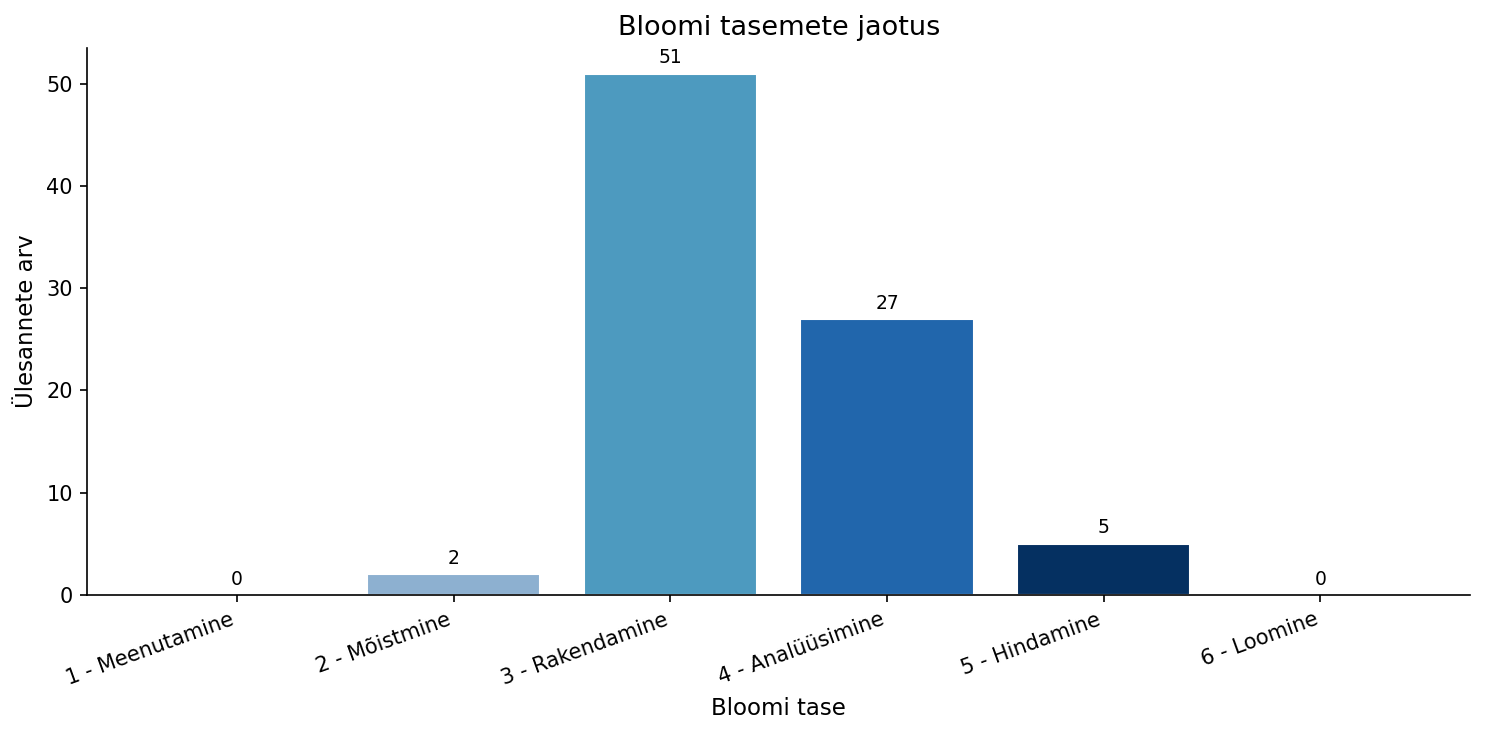

Saved


In [7]:
# Kohustuslikud
bloom_counts = (
    df_mandatory["Bloomi tase"]
    .value_counts()
    .reindex(BLOOM_ORDER, fill_value=0)
)

fig, ax = plt.subplots()
colours = [BLOOM_COLOURS.get(b, "#aaaaaa") for b in bloom_counts.index]
bars = ax.bar(bloom_counts.index, bloom_counts.values, color=colours, edgecolor="white")
ax.set_xlabel("Bloomi tase")
ax.set_ylabel("Ülesannete arv")
ax.set_title("Bloomi tasemete jaotus")
ax.bar_label(bars, padding=3, fontsize=9)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("fig3_bloom_overall_mandatory.png", bbox_inches="tight")
plt.show()
print("Saved")


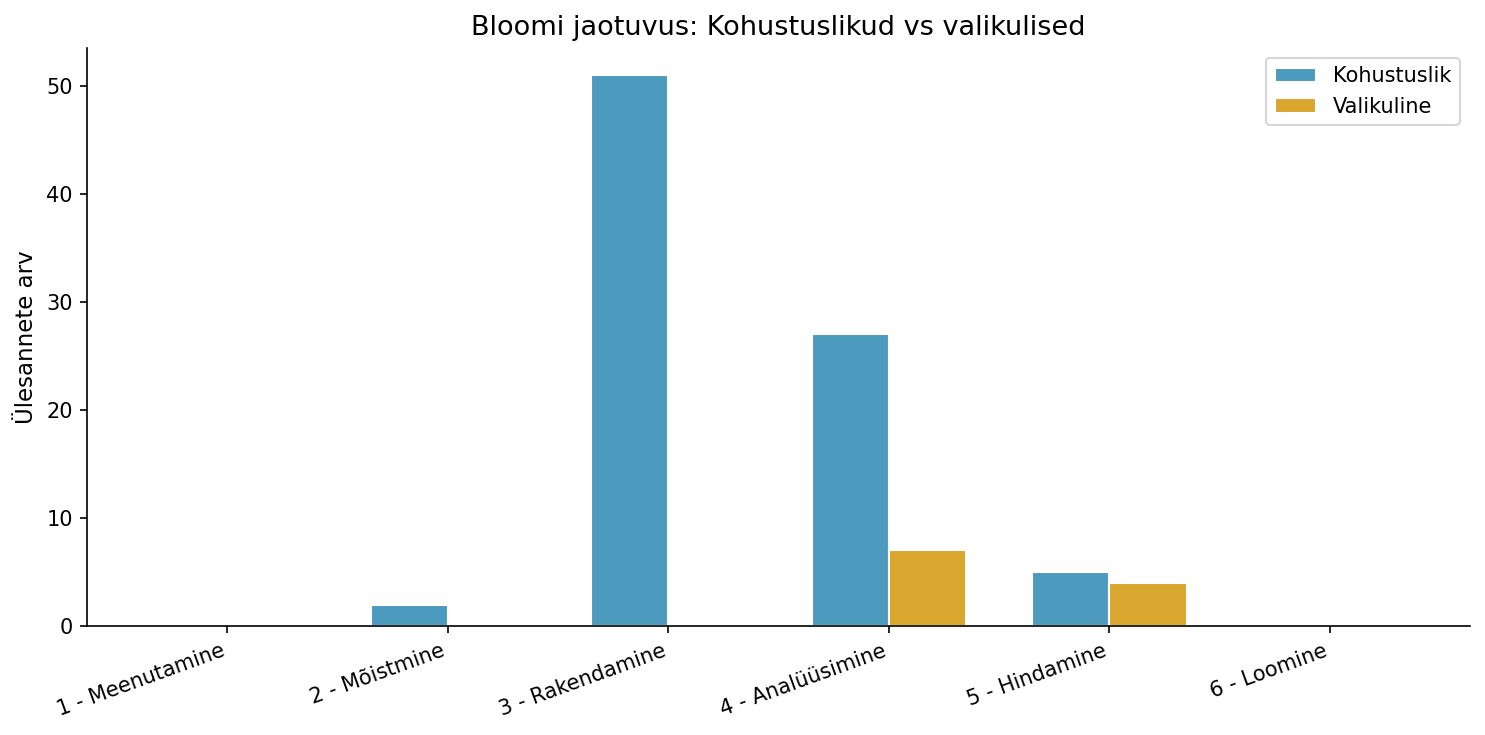

Saved


In [8]:
# 3.2 Bloomi jaotuvus koos lisadül.
bloom_mand = (
    df_mandatory["Bloomi tase"]
    .value_counts()
    .reindex(BLOOM_ORDER, fill_value=0)
)
bloom_opt = (
    df_optional["Bloomi tase"]
    .value_counts()
    .reindex(BLOOM_ORDER, fill_value=0)
)

x = np.arange(len(BLOOM_ORDER))
width = 0.35

fig, ax = plt.subplots()
ax.bar(x - width/2, bloom_mand.values, width, label="Kohustuslik", color="#4d9abf", edgecolor="white")
ax.bar(x + width/2, bloom_opt.values,  width, label="Valikuline", color="#d9a62e", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(BLOOM_ORDER, rotation=20, ha="right")
ax.set_ylabel("Ülesannete arv")
ax.set_title("Bloomi jaotuvus: Kohustuslikud vs valikulised")
ax.legend()
plt.tight_layout()
plt.savefig("fig4_bloom_mandatory_vs_optional.png", bbox_inches="tight")
plt.show()
print("Saved")


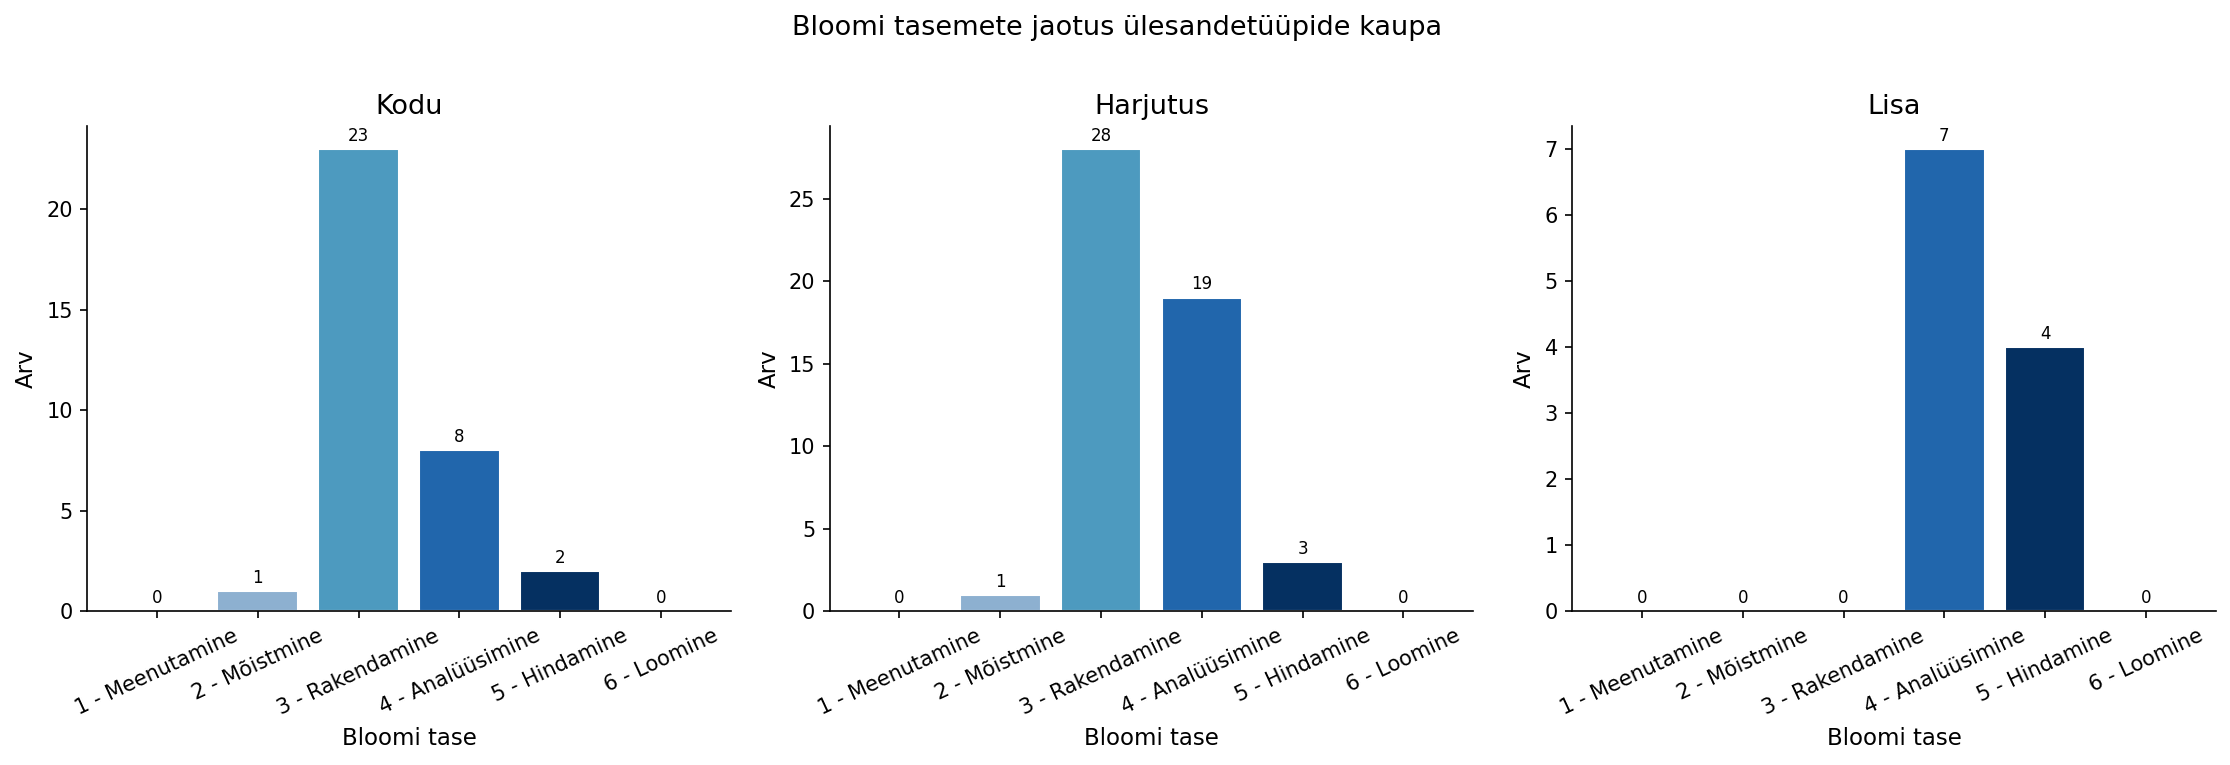

Saved


In [9]:
# 3.3 Bloom ülesande tüüpide järgi
bloom_by_type = (
    df.groupby(["Tüüp", "Bloomi tase"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=BLOOM_ORDER, fill_value=0)
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
for ax, ttype in zip(axes, ["Kodu", "Harjutus", "Lisa"]):
    if ttype not in bloom_by_type.index:
        ax.set_visible(False)
        continue
    vals = bloom_by_type.loc[ttype]
    colours = [BLOOM_COLOURS.get(b, "#aaaaaa") for b in vals.index]
    bars = ax.bar(vals.index, vals.values, color=colours, edgecolor="white")
    ax.set_title(f"{ttype}")
    ax.set_xlabel("Bloomi tase")
    ax.set_ylabel("Arv")
    ax.bar_label(bars, padding=2, fontsize=8)
    ax.tick_params(axis="x", rotation=25)

fig.suptitle("Bloomi tasemete jaotus ülesandetüüpide kaupa", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("fig5_bloom_by_type.png", bbox_inches="tight")
plt.show()
print("Saved")


In [22]:
# 3.3.1
# for Table 3: Bloom distribution by type
bloom_table = (
    df.groupby(["Bloomi tase", "Tüüp"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=BLOOM_ORDER, columns=["Kodu", "Harjutus", "Lisa"], fill_value=0)
)

total_kodu = len(df[df["Tüüp"] == "Kodu"])
total_harjutus = len(df[df["Tüüp"] == "Harjutus"])
total_lisa = len(df[df["Tüüp"] == "Lisa"])

bloom_table["Kodu%"] = (bloom_table["Kodu"] / total_kodu * 100).round(1)
bloom_table["Harjutus%"] = (bloom_table["Harjutus"] / total_harjutus * 100).round(1)
bloom_table["Lisa%"] = (bloom_table["Lisa"] / total_lisa * 100).round(1)

print(bloom_table[["Kodu", "Kodu%", "Harjutus", "Harjutus%", "Lisa", "Lisa%"]].to_string())

Tüüp              Kodu  Kodu%  Harjutus  Harjutus%  Lisa  Lisa%
Bloomi tase                                                    
1 - Meenutamine      0    0.0         0        0.0     0    0.0
2 - Mõistmine        1    2.9         1        2.0     0    0.0
3 - Rakendamine     23   67.6        28       54.9     0    0.0
4 - Analüüsimine     8   23.5        19       37.3     7   63.6
5 - Hindamine        2    5.9         3        5.9     4   36.4
6 - Loomine          0    0.0         0        0.0     0    0.0


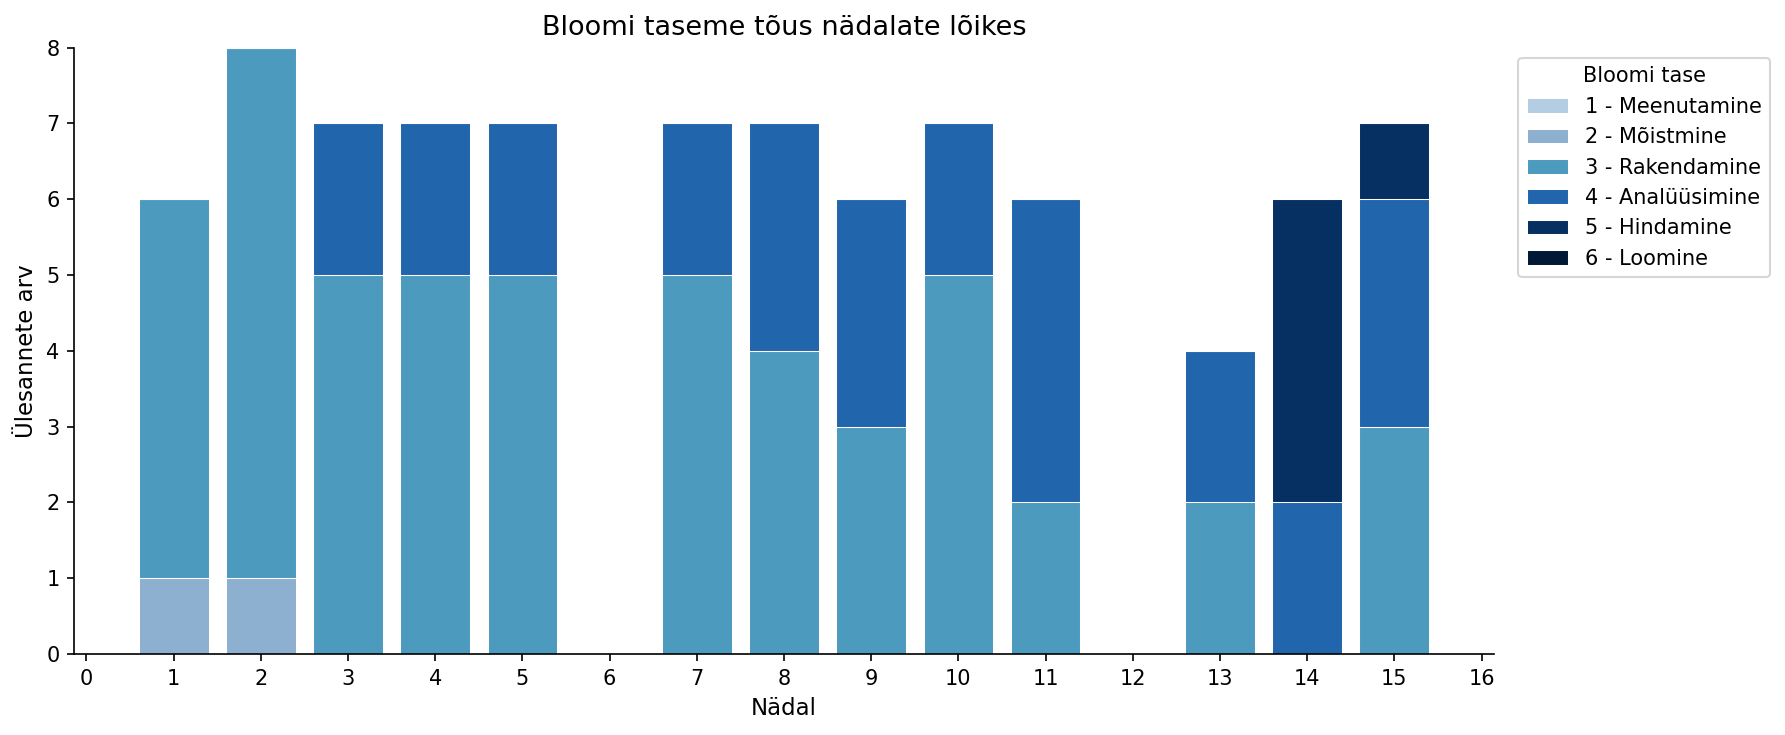

Saved


In [10]:
# 3.4 Bloomi tase nädalate kaupa
bloom_week = (
    df_mandatory.groupby(["Nädal", "Bloomi tase"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=BLOOM_ORDER, fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 5))
bottom = np.zeros(len(bloom_week))
for level in BLOOM_ORDER:
    if level not in bloom_week.columns:
        continue
    vals = bloom_week[level].values
    ax.bar(
        bloom_week.index,
        vals,
        bottom=bottom,
        label=level,
        color=BLOOM_COLOURS.get(level, "#aaaaaa"),
        edgecolor="white",
        linewidth=0.5,
    )
    bottom += vals

ax.set_xlabel("Nädal")
ax.set_ylabel("Ülesannete arv")
ax.set_title("Bloomi taseme tõus nädalate lõikes")
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.legend(title="Bloomi tase", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig("fig6_bloom_progression.png", bbox_inches="tight")
plt.show()
print("Saved")


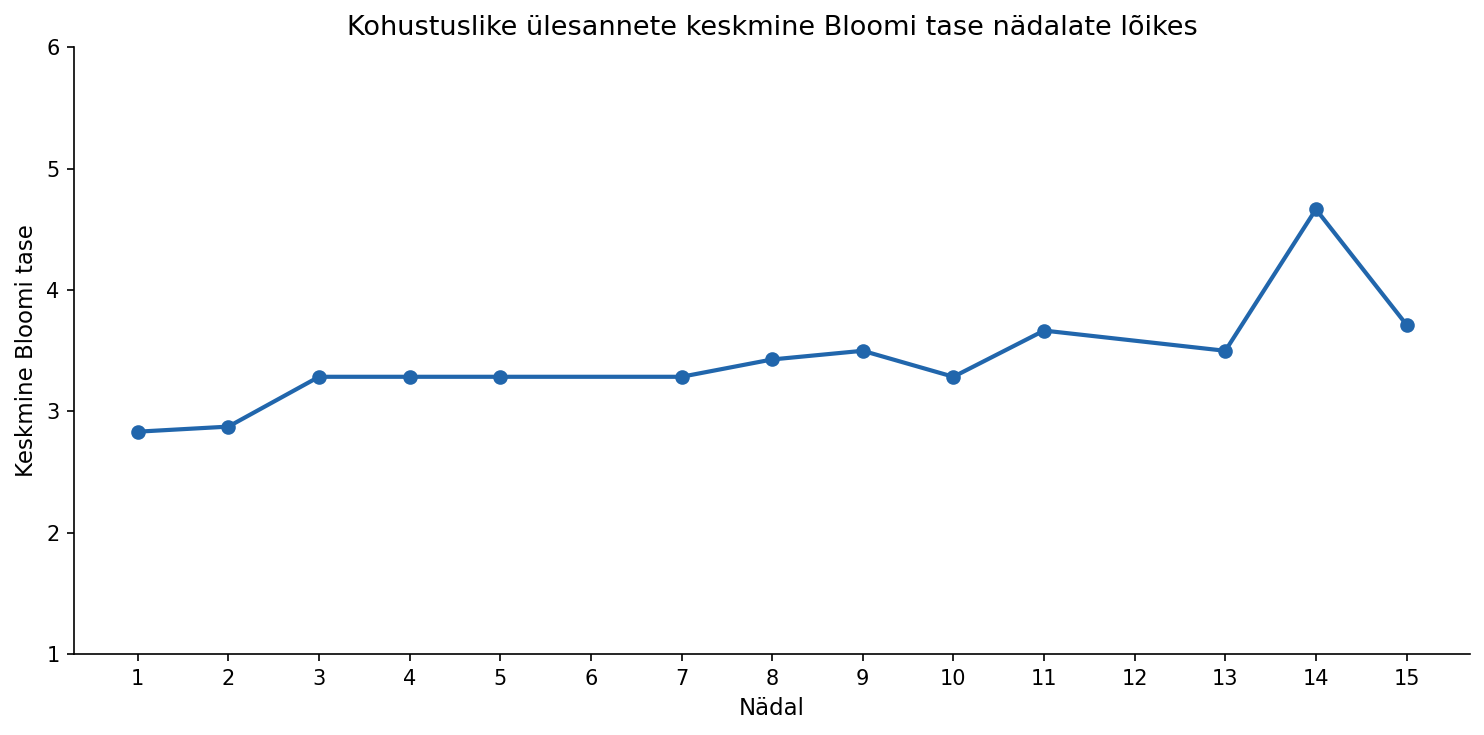

Saved


In [11]:
# Keskmine Bloomi tase nädalate lõikes
avg_bloom_week = (
    df_mandatory.groupby("Nädal")["Bloom_num"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    avg_bloom_week["Nädal"],
    avg_bloom_week["Bloom_num"],
    color="#2166ac",
    linewidth=2,
    marker="o",
    markersize=6,
)
ax.set_xlabel("Nädal")
ax.set_ylabel("Keskmine Bloomi tase")
ax.set_title("Kohustuslike ülesannete keskmine Bloomi tase nädalate lõikes")
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.set_ylim(1, 6)
ax.yaxis.set_major_locator(mticker.MultipleLocator(1))
plt.tight_layout()
plt.savefig("fig_avg_bloom_per_week.png", bbox_inches="tight")
plt.show()
print("Saved")

---
## 4. Õpiväljundid

Õpiväljundid:
- **ÕV1** — Põhikonstruktsioonid
- **ÕV2** — Andmetüübid ja -struktuurid
- **ÕV3** — Analüüsimine ja muutmine
- **ÕV4** — Algoritm, lahendus, silumine
- **ÕV5** — Rühmatöö


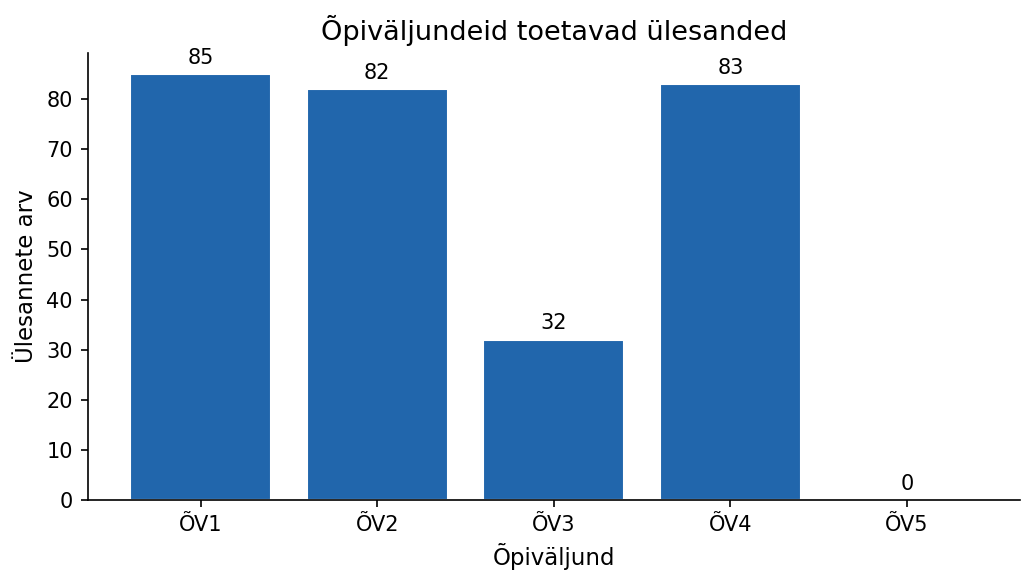

Saved


In [12]:
# 4.1 Õpiväljundeid toetavad ülesanded
ov_totals_mand = df_mandatory[ov_cols].sum()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    ov_totals_mand.index,
    ov_totals_mand.values,
    color="#2166ac",
    edgecolor="white",
)
ax.set_xlabel("Õpiväljund")
ax.set_ylabel("Ülesannete arv")
ax.set_title("Õpiväljundeid toetavad ülesanded")
ax.bar_label(bars, padding=3, fontsize=10)
plt.tight_layout()
plt.savefig("fig7_ov_coverage_mandatory.png", bbox_inches="tight")
plt.show()
print("Saved")


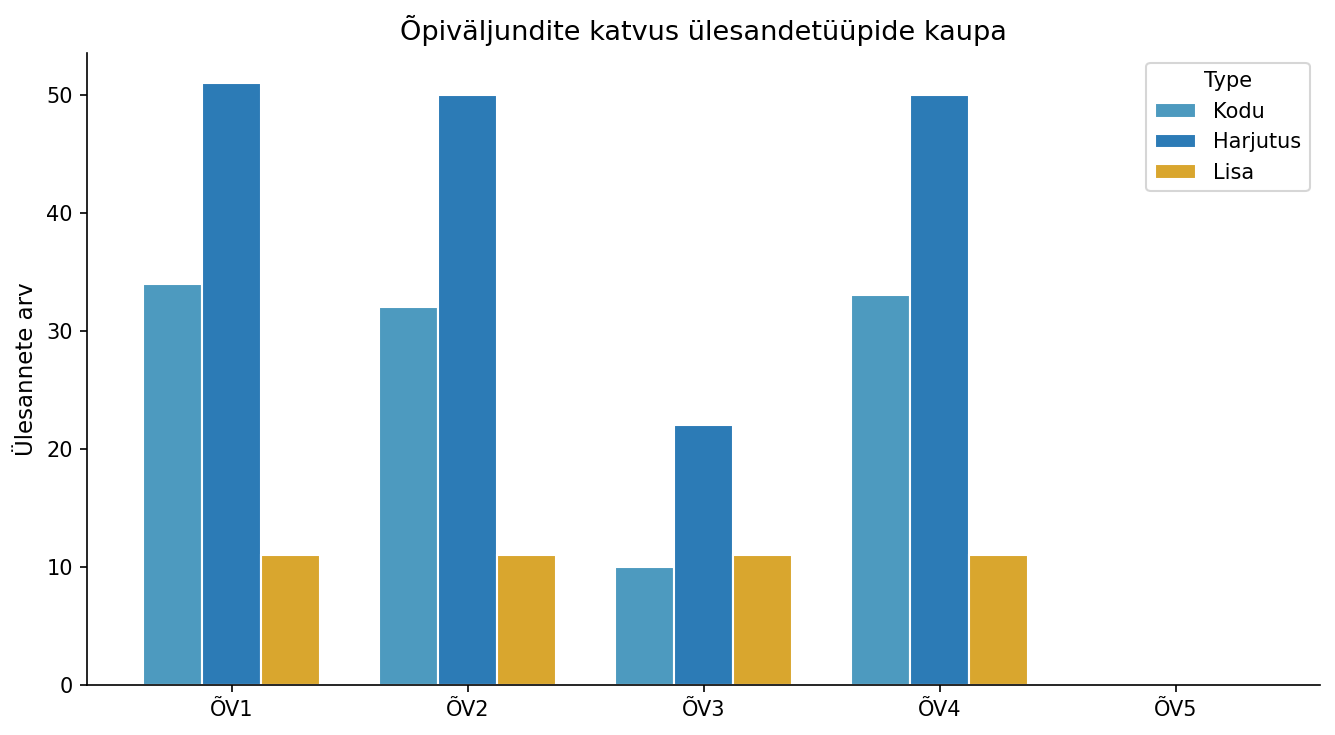

Saved


In [13]:
# 4.2 ÕV ülesande tüüpide järgi
ov_by_type = df.groupby("Tüüp")[ov_cols].sum().reindex(["Kodu", "Harjutus", "Lisa"])

x = np.arange(len(ov_cols))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
for i, ttype in enumerate(["Kodu", "Harjutus", "Lisa"]):
    ax.bar(
        x + (i - 1) * width,
        ov_by_type.loc[ttype],
        width,
        label=ttype,
        color=TYPE_COLOURS[ttype],
        edgecolor="white",
    )

ax.set_xticks(x)
ax.set_xticklabels(ov_cols)
ax.set_ylabel("Ülesannete arv")
ax.set_title("Õpiväljundite katvus ülesandetüüpide kaupa")
ax.legend(title="Type")
plt.tight_layout()
plt.savefig("fig8_ov_by_type.png", bbox_inches="tight")
plt.show()
print("Saved")


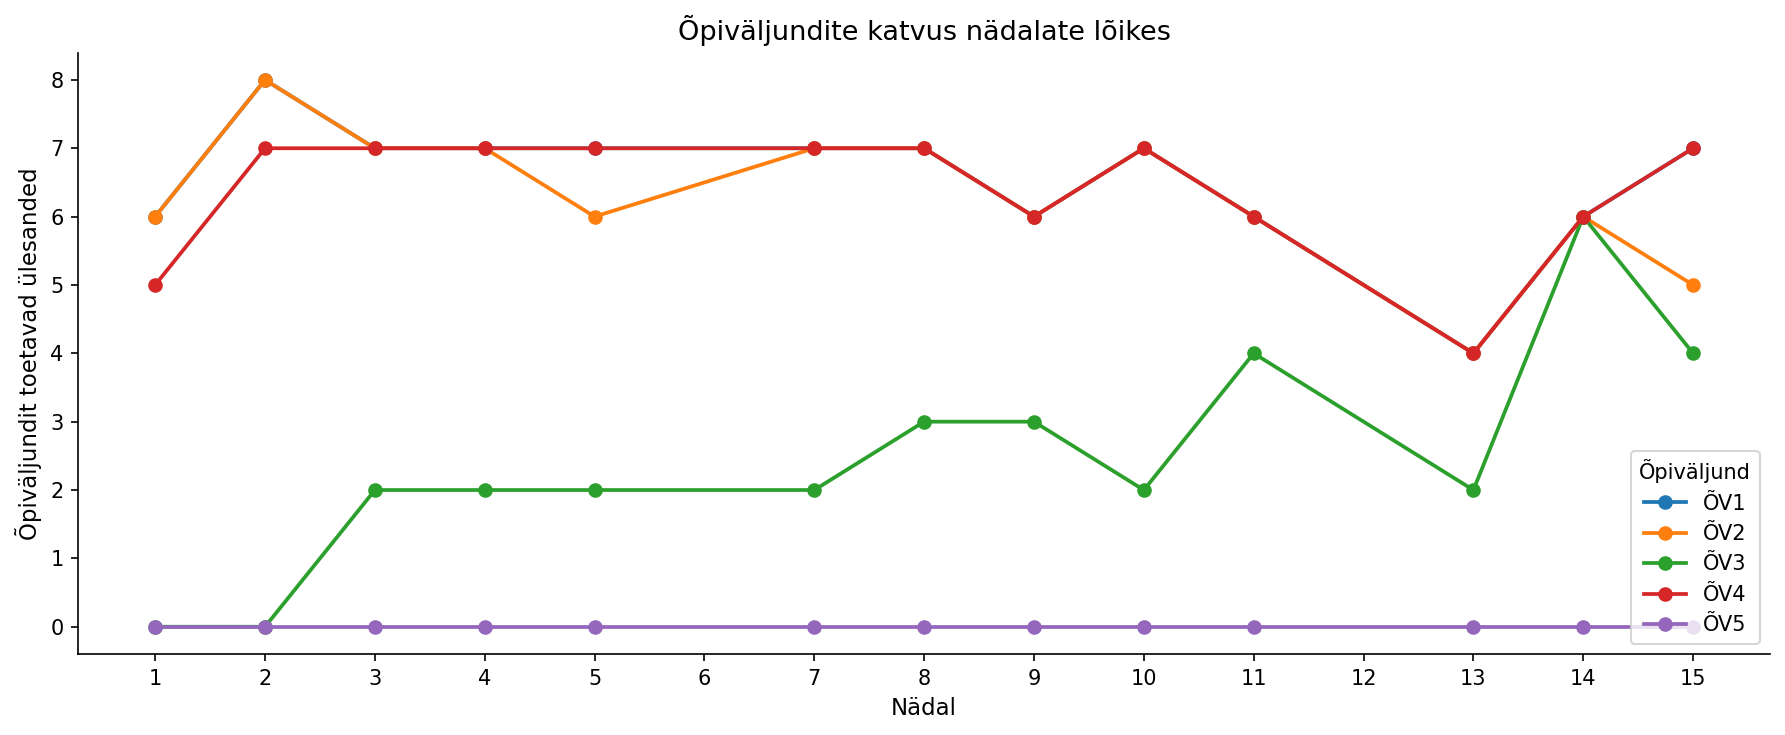

Saved


In [14]:
# 4.3 ÕV katvus üle nädalate
ov_week = df_mandatory.groupby("Nädal")[ov_cols].sum()

fig, ax = plt.subplots(figsize=(12, 5))
for ov in ov_cols:
    ax.plot(
        ov_week.index,
        ov_week[ov],
        marker="o",
        linewidth=1.8,
        label=ov,
    )

ax.set_xlabel("Nädal")
ax.set_ylabel("Õpiväljundit toetavad ülesanded")
ax.set_title("Õpiväljundite katvus nädalate lõikes")
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.legend(title="Õpiväljund")
plt.tight_layout()
plt.savefig("fig9_ov_across_weeks.png", bbox_inches="tight")
plt.show()
print("Saved")


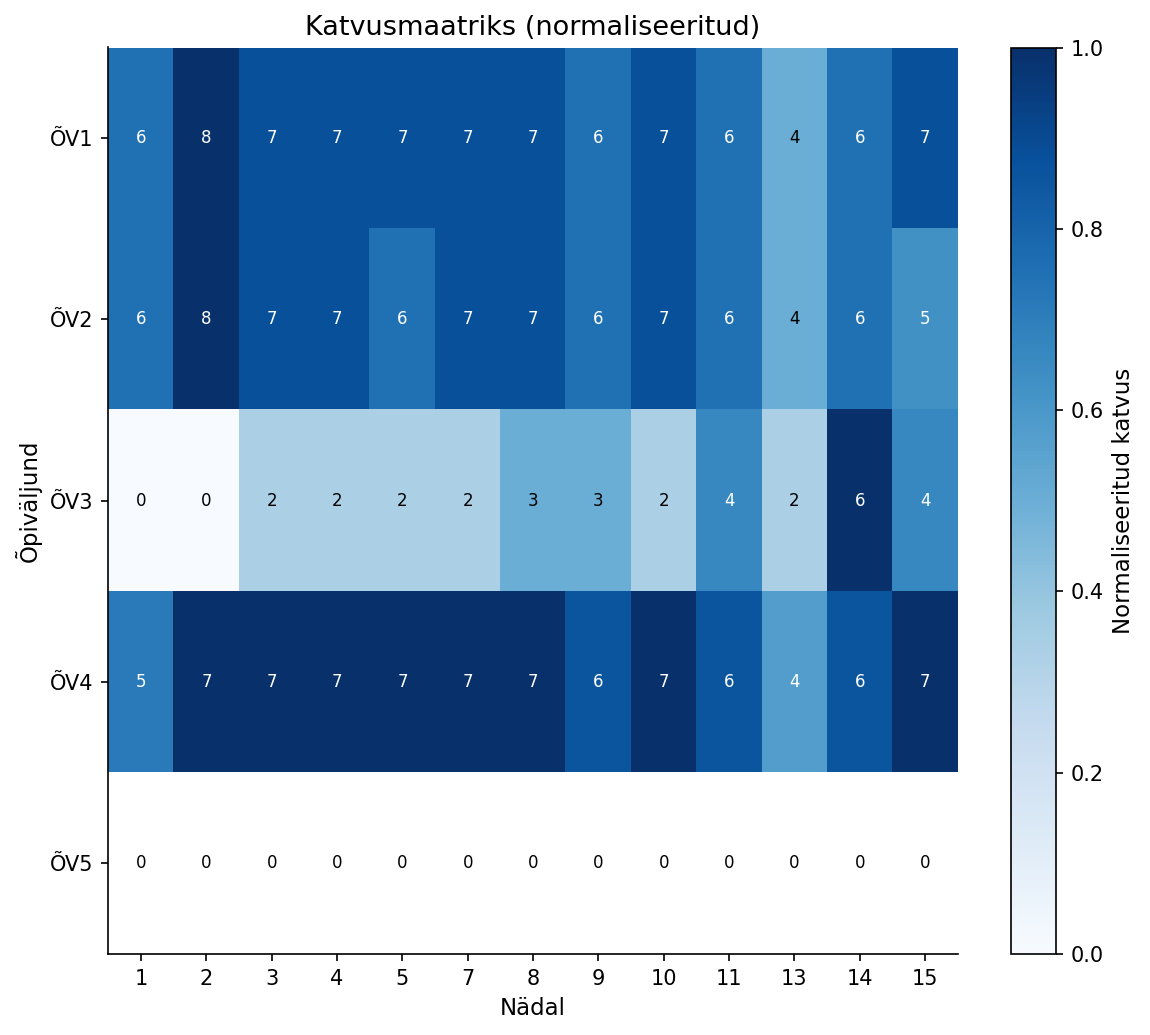

Saved


In [15]:
# 4.4 Katvusmaatriks
ov_week_norm = ov_week.div(ov_week.max(axis=0), axis=1)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(ov_week_norm.T, aspect="auto", cmap="Blues", vmin=0, vmax=1)

ax.set_xticks(range(len(ov_week.index)))
ax.set_xticklabels(ov_week.index)
ax.set_yticks(range(len(ov_cols)))
ax.set_yticklabels(ov_cols)
ax.set_xlabel("Nädal")
ax.set_ylabel("Õpiväljund")
ax.set_title("Katvusmaatriks (normaliseeritud)")

# Annotate raw counts
for i, ov in enumerate(ov_cols):
    for j, week in enumerate(ov_week.index):
        val = ov_week.loc[week, ov]
        ax.text(j, i, str(int(val)), ha="center", va="center",
                fontsize=8, color="white" if ov_week_norm.loc[week, ov] > 0.5 else "black")

plt.colorbar(im, ax=ax, label="Normaliseeritud katvus")
plt.tight_layout()
plt.savefig("fig10_coverage_matrix.png", bbox_inches="tight")
plt.show()
print("Saved")


---
## 5. Ülesande tüüpide võrdlus


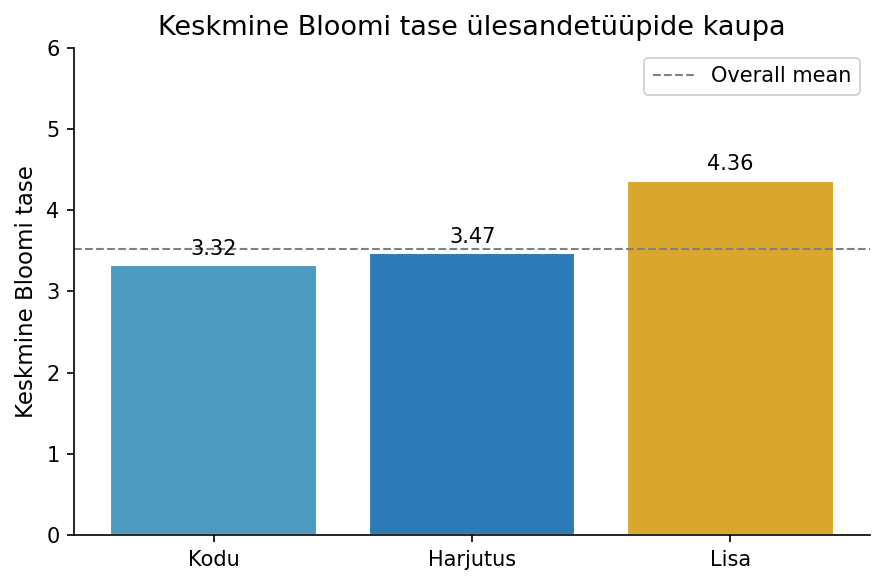

Saved


In [16]:
# 5.1 Keskmine Bloomi tase tüübi järgi

df["Bloom_num"] = df["Bloomi tase"].str.extract(r"(\d)").astype(float)

avg_bloom = df.groupby("Tüüp")["Bloom_num"].mean().reindex(["Kodu", "Harjutus", "Lisa"])

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    avg_bloom.index,
    avg_bloom.values,
    color=[TYPE_COLOURS[t] for t in avg_bloom.index],
    edgecolor="white",
)
ax.set_ylim(0, 6)
ax.set_ylabel("Keskmine Bloomi tase")
ax.set_title("Keskmine Bloomi tase ülesandetüüpide kaupa")
ax.axhline(df["Bloom_num"].mean(), color="grey", linestyle="--", linewidth=1, label="Overall mean")
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=10)
ax.legend()
plt.tight_layout()
plt.savefig("fig11_avg_bloom_by_type.png", bbox_inches="tight")
plt.show()
print("Saved")


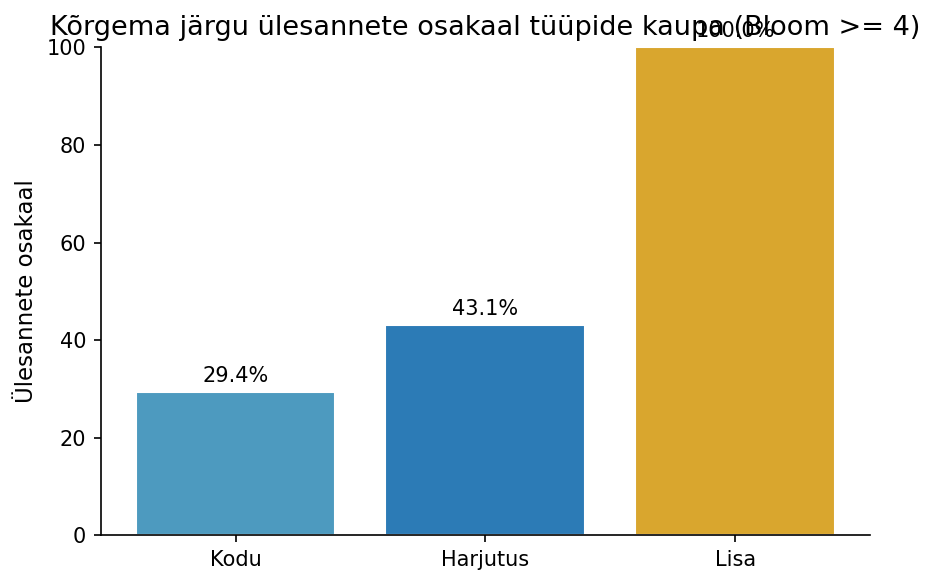

Saved


In [17]:
# Kõrgema järgu ülesannete osakaal tüüpide kaupa (tase ≥ 4)
df["Higher_order"] = df["Bloom_num"] >= 4

ho_pct = (
    df.groupby("Tüüp")["Higher_order"]
    .mean()
    .reindex(["Kodu", "Harjutus", "Lisa"]) * 100
)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ho_pct.index,
    ho_pct.values,
    color=[TYPE_COLOURS[t] for t in ho_pct.index],
    edgecolor="white",
)
ax.set_ylim(0, 100)
ax.set_ylabel("Ülesannete osakaal")
ax.set_title("Kõrgema järgu ülesannete osakaal tüüpide kaupa (Bloom >= 4)")
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=10)
plt.tight_layout()
plt.savefig("fig12_higher_order_pct.png", bbox_inches="tight")
plt.show()
print("Saved")


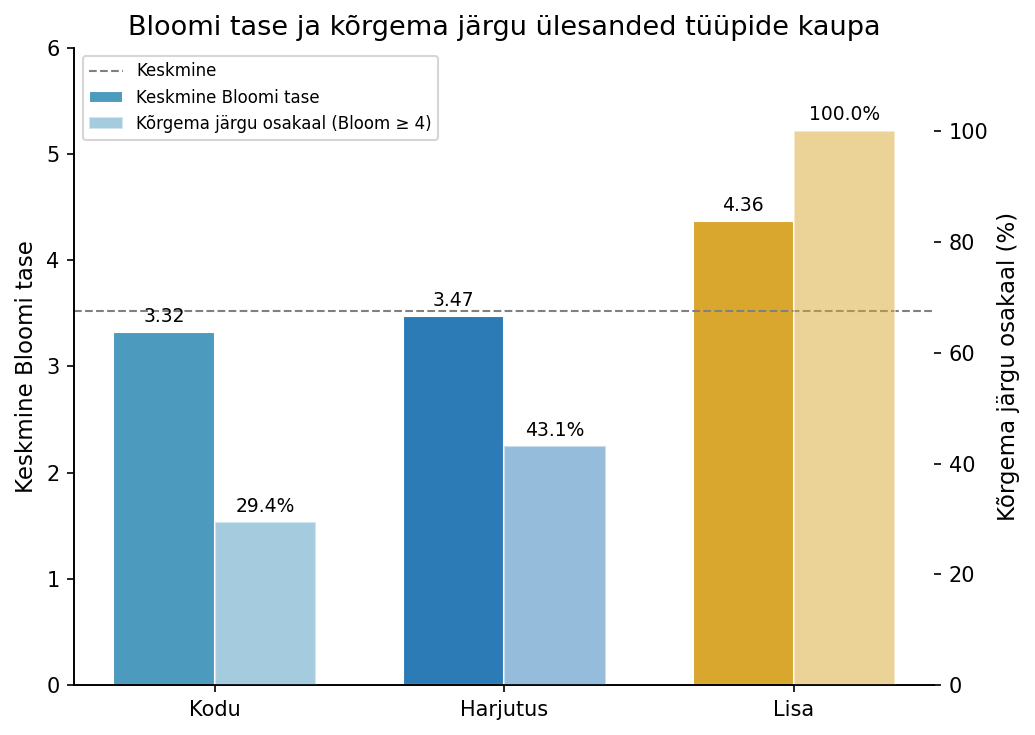

In [18]:
# Joonis 11 ja 12 koos
fig, ax1 = plt.subplots(figsize=(7, 5))
ax2 = ax1.twinx()

types = ["Kodu", "Harjutus", "Lisa"]
x = range(len(types))
bar_width = 0.35

avg_bloom = df.groupby("Tüüp")["Bloom_num"].mean().reindex(types)
bars1 = ax1.bar(
    [i - bar_width / 2 for i in x],
    avg_bloom.values,
    width=bar_width,
    color=[TYPE_COLOURS[t] for t in types],
    edgecolor="white",
    label="Keskmine Bloomi tase",
)
ax1.set_ylim(0, 6)
ax1.set_ylabel("Keskmine Bloomi tase")
ax1.axhline(df["Bloom_num"].mean(), color="grey", linestyle="--", linewidth=1, label="Keskmine")
ax1.bar_label(bars1, fmt="%.2f", padding=3, fontsize=9)

df["Higher_order"] = df["Bloom_num"] >= 4
ho_pct = df.groupby("Tüüp")["Higher_order"].mean().reindex(types) * 100
bars2 = ax2.bar(
    [i + bar_width / 2 for i in x],
    ho_pct.values,
    width=bar_width,
    color=[TYPE_COLOURS[t] for t in types],
    edgecolor="white",
    alpha=0.5,
    label="Kõrgema järgu osakaal (Bloom ≥ 4)",
)
ax2.set_ylim(0, 115)
ax2.set_ylabel("Kõrgema järgu osakaal (%)")
ax2.bar_label(bars2, fmt="%.1f%%", padding=3, fontsize=9)

ax1.set_xticks(list(x))
ax1.set_xticklabels(types)
ax1.set_title("Bloomi tase ja kõrgema järgu ülesanded tüüpide kaupa")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper left")

plt.tight_layout()
plt.savefig("fig11_12_combined.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 6. Kohustuslikd vs vabatahtlikud ülesanded


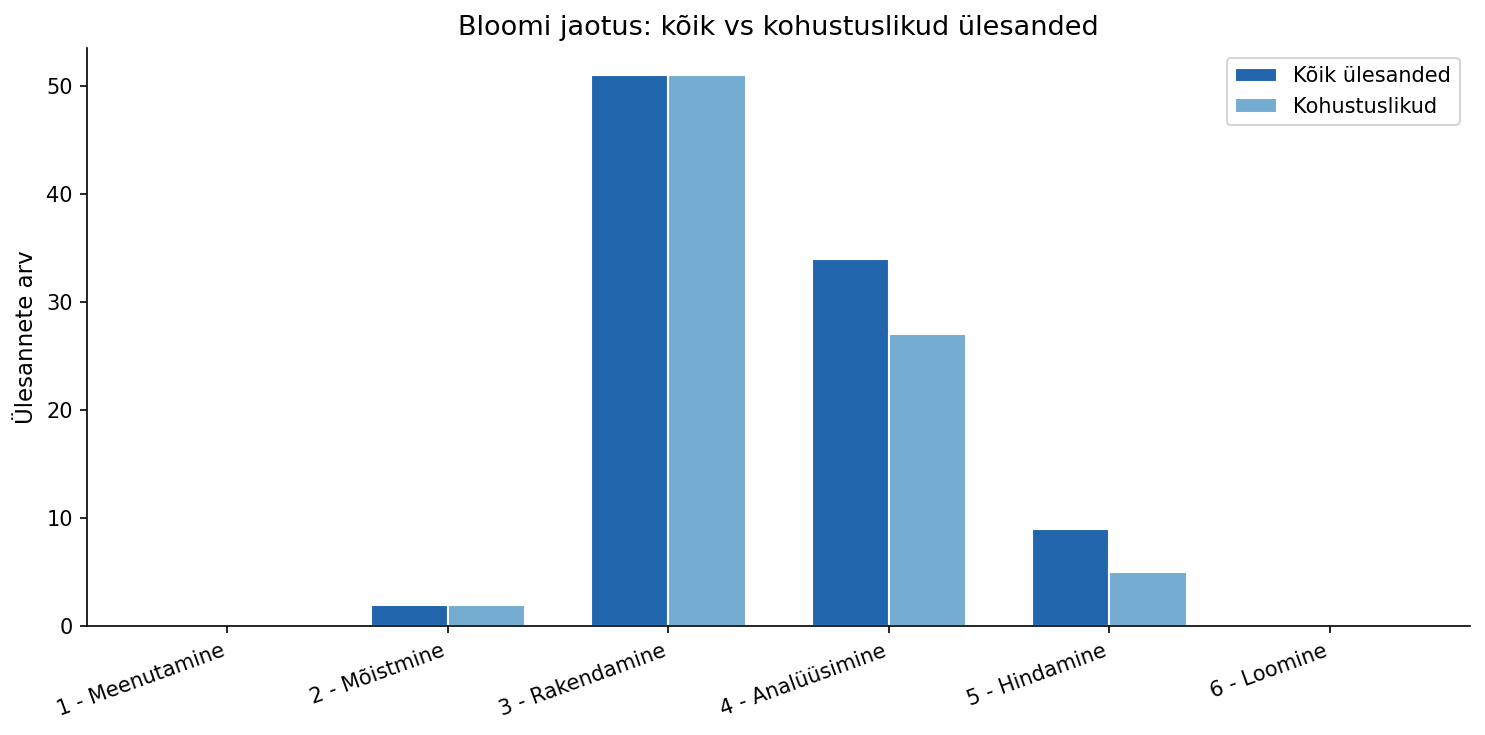

Saved


In [19]:
# 6.1 Bloomi jaotuvus: koos ja ilma lisadeta
bloom_all  = df["Bloomi tase"].value_counts().reindex(BLOOM_ORDER, fill_value=0)
bloom_mand2 = df_mandatory["Bloomi tase"].value_counts().reindex(BLOOM_ORDER, fill_value=0)

x = np.arange(len(BLOOM_ORDER))
width = 0.35

fig, ax = plt.subplots()
ax.bar(x - width/2, bloom_all.values,   width, label="Kõik ülesanded",       color="#2166ac", edgecolor="white")
ax.bar(x + width/2, bloom_mand2.values, width, label="Kohustuslikud",      color="#74add1", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(BLOOM_ORDER, rotation=20, ha="right")
ax.set_ylabel("Ülesannete arv")
ax.set_title("Bloomi jaotus: kõik vs kohustuslikud ülesanded")
ax.legend()
plt.tight_layout()
plt.savefig("fig13_mandatory_vs_all_bloom.png", bbox_inches="tight")
plt.show()
print("Saved")


In [20]:
# 6.2 Tase 5 esinemine
level5 = df[df["Bloom_num"] == 5][["Nädal", "Tüüp", "Kohustuslik", "ÜL_ID", "ÜL_nimi", "Bloomi tase"]]
print("Kõik hindamistaseme (5) ülesanded:")
print(level5.to_string(index=False))


Kõik hindamistaseme (5) ülesanded:
 Nädal     Tüüp Kohustuslik  ÜL_ID                      ÜL_nimi   Bloomi tase
     4     Lisa          Ei    4.8         Lahingu simulatsioon 5 - Hindamine
     9     Lisa          Ei    9.3 Determinant Sarruse reegliga 5 - Hindamine
    13     Lisa          Ei   13.2        Tõukerataste laenutus 5 - Hindamine
    13     Lisa          Ei   13.6                     Eellased 5 - Hindamine
    14     Kodu         Jah 14.1.1                       Garaaž 5 - Hindamine
    14     Kodu         Jah 14.1.2                 Kaardimaksed 5 - Hindamine
    14 Harjutus         Jah   14.3                    Draakonid 5 - Hindamine
    14 Harjutus         Jah   14.5                  Täringumäng 5 - Hindamine
    15 Harjutus         Jah   15.7                    Fraktalid 5 - Hindamine


---
## 7. Kokkuvõttev statistika


In [21]:
total      = len(df)
total_mand = len(df_mandatory)
total_opt  = len(df_optional)

bloom_dist_mand = df_mandatory["Bloomi tase"].value_counts().reindex(BLOOM_ORDER, fill_value=0)
dominant_level  = bloom_dist_mand.idxmax()
dominant_pct    = bloom_dist_mand.max() / total_mand * 100

ho_mand_pct = (df_mandatory["Bloom_num"] >= 4).mean() * 100
ho_opt_pct  = (df_optional["Bloom_num"] >= 4).mean() * 100

ov5_count   = df_mandatory["ÕV5"].sum()
ov5_pct     = ov5_count / total_mand * 100

print("=" * 55)
print("PEAMISED TULEMUSED")
print("=" * 55)
print(f"Ülesandeid kokku (kordamisnädalateta): {total}")
print(f"  Kohustuslikud:                       {total_mand}")
print(f"  Vabatahtlikud (Lisa):                {total_opt}")
print()
print(f"Domineeriv Bloomi tase (kohustuslikud): {dominant_level}")
print(f"  Osakaal kohustuslikest ülesannetest:  {dominant_pct:.1f}%")
print()
print(f"Kõrgema järgu ülesanded (tase >= 4):")
print(f"  Kohustuslikud:                        {ho_mand_pct:.1f}%")
print(f"  Vabatahtlikud (Lisa):                 {ho_opt_pct:.1f}%")
print()
print(f"ÕV5 (rühmatöö) katvus:")
print(f"  ÕV5 toetavad ülesanded:               {ov5_count} ({ov5_pct:.1f}%)")
print()
print("Õpiväljundite katvus:")
for ov in ov_cols:
    n = df_mandatory[ov].sum()
    pct = n / total_mand * 100
    print(f"  {ov}: {n} ülesannet ({pct:.1f}%)")
print("=" * 55)


PEAMISED TULEMUSED
Ülesandeid kokku (kordamisnädalateta): 96
  Kohustuslikud:                       85
  Vabatahtlikud (Lisa):                11

Domineeriv Bloomi tase (kohustuslikud): 3 - Rakendamine
  Osakaal kohustuslikest ülesannetest:  60.0%

Kõrgema järgu ülesanded (tase >= 4):
  Kohustuslikud:                        37.6%
  Vabatahtlikud (Lisa):                 100.0%

ÕV5 (rühmatöö) katvus:
  ÕV5 toetavad ülesanded:               0 (0.0%)

Õpiväljundite katvus:
  ÕV1: 85 ülesannet (100.0%)
  ÕV2: 82 ülesannet (96.5%)
  ÕV3: 32 ülesannet (37.6%)
  ÕV4: 83 ülesannet (97.6%)
  ÕV5: 0 ülesannet (0.0%)
